In [4]:
import zipfile

with zipfile.ZipFile('Devanagari.zip', 'r') as z:
    z.extractall('/content/')

print("Extracted successfully!")

Extracted successfully!


In [5]:
!ls /content/Devanagari/

Test  Train


In [6]:
!ls /content/Devanagari/Train/

digit_0  digit_1  digit_2


In [11]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image

In [8]:
train_dir = "/content/Devanagari/Train/"
test_dir  = "/content/Devanagari/Test/"
img_height, img_width = 28, 28

def load_images_from_folder(folder):
    images, labels = [], []
    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            img = Image.open(img_path).convert("L")
            img = img.resize((img_width, img_height))
            img = np.array(img) / 255.0
            images.append(img)
            labels.append(class_map[class_name])

    return np.array(images), np.array(labels)

x_train, y_train = load_images_from_folder(train_dir)
x_test,  y_test  = load_images_from_folder(test_dir)

print("x_train:", x_train.shape)
print("x_test: ", x_test.shape)

x_train: (4934, 28, 28)
x_test:  (3000, 28, 28)


In [9]:
# Flatten images for FCN input
x_train = x_train.reshape(-1, img_height * img_width)
x_test  = x_test.reshape(-1, img_height * img_width)

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat  = to_categorical(y_test,  num_classes=10)

print("x_train:", x_train.shape, "y_train:", y_train_cat.shape)
print("x_test: ", x_test.shape,  "y_test: ", y_test_cat.shape)

x_train: (4934, 784) y_train: (4934, 10)
x_test:  (3000, 784) y_test:  (3000, 10)


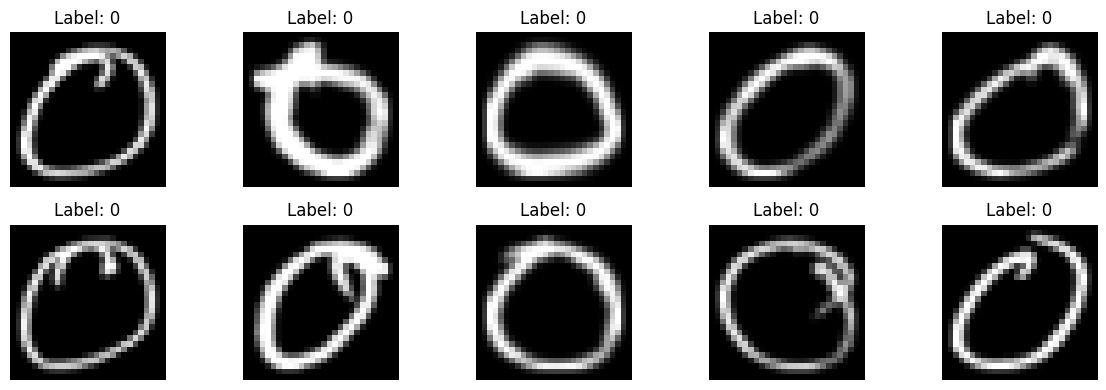

In [12]:
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [13]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(64,  activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(10,  activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [15]:
from tensorflow import keras

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="/content/best_model.keras",
        save_best_only=True,
        monitor="val_loss"
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )
]

history = model.fit(
    x_train, y_train_cat,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5807 - loss: 1.1382 - val_accuracy: 0.0000e+00 - val_loss: 1.7854
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8538 - loss: 0.5223 - val_accuracy: 0.2097 - val_loss: 1.1203
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9592 - loss: 0.1791 - val_accuracy: 0.9189 - val_loss: 0.3993
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9934 - loss: 0.0625 - val_accuracy: 0.9737 - val_loss: 0.1445
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9959 - loss: 0.0312 - val_accuracy: 0.9807 - val_loss: 0.0784
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9962 - loss: 0.0195 - val_accuracy: 0.9787 - val_loss: 0.0789
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9975 - loss: 0.0139 - val_accuracy: 0.9838 - val_loss: 0.0630
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9985 - loss: 0.0099 - val_accuracy: 0.9868 

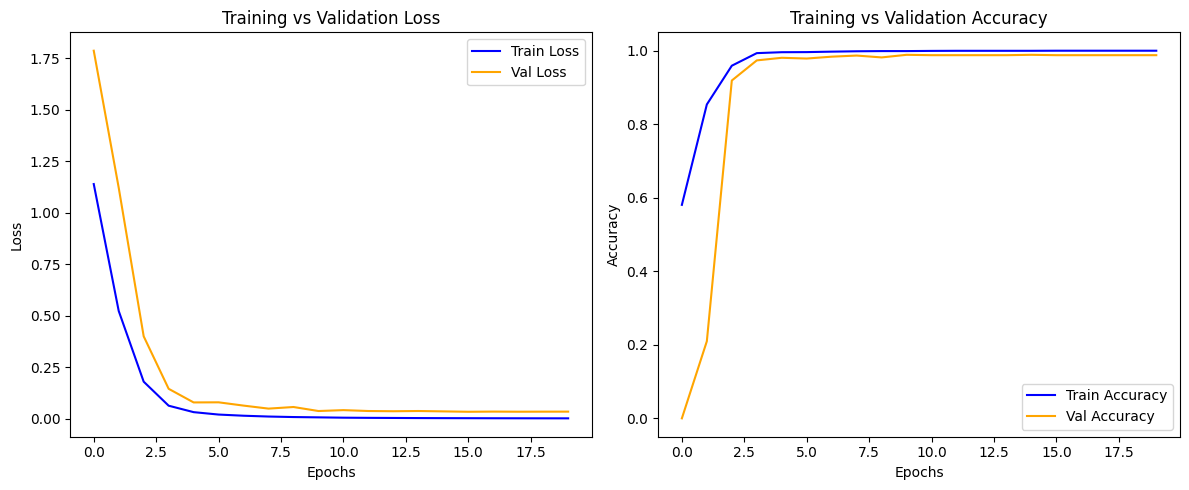

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Train Loss',     color='blue')
plt.plot(history.history['val_loss'], label='Val Loss',       color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'],     label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=2)
print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

94/94 - 0s - 2ms/step - accuracy: 0.2977 - loss: 7.5027

Test Loss:     7.5027
Test Accuracy: 0.2977


In [18]:
model.save('/content/devnagari_fcn_model.h5')
print("Model saved successfully!")

Model saved successfully!


In [19]:
loaded_model = tf.keras.models.load_model('/content/devnagari_fcn_model.h5')
print("Model loaded successfully!")

loss, acc = loaded_model.evaluate(x_test, y_test_cat, verbose=2)
print(f"\nLoaded Model Test Loss:     {loss:.4f}")
print(f"Loaded Model Test Accuracy: {acc:.4f}")

Model loaded successfully!
94/94 - 1s - 6ms/step - accuracy: 0.2977 - loss: 7.5027

Loaded Model Test Loss:     7.5027
Loaded Model Test Accuracy: 0.2977


In [20]:
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image:      {y_test[0]}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted label for first image: 0
True label for first image:      0


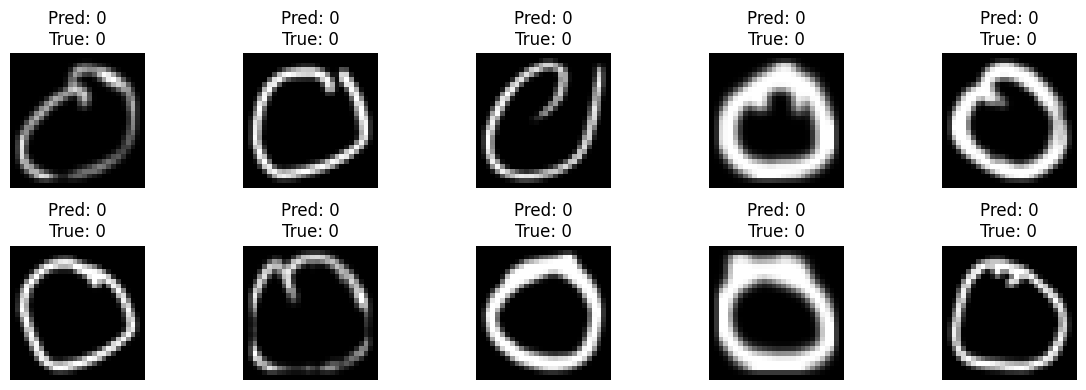

In [21]:
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {predicted_labels[i]}\nTrue: {y_test[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()